# Mini Project: Final Report

**Course:** CS 436/536 — Intro to Machine Learning


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Presentation settings: readable tables, no scientific notation
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 60)

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("open-source-sports/baseball-databank")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'baseball-databank' dataset.
Path to dataset files: /kaggle/input/baseball-databank


## 1. Problem Statement & Dataset

**Dataset name:** Baseball Databank (Lahman Baseball Database)

**Dataset source:** Kaggle — `open-source-sports/baseball-databank`
(https://www.kaggle.com/datasets/open-source-sports/baseball-databank)

**Machine learning task:** Supervised regression. We predict a player's salary for a
given season from that season's performance statistics.

**Target variable:** `salary` (US dollars, not inflation-adjusted).

We use three of the tables in the database:

| File | Rows | Columns | Contents |
|---|---|---|---|
| `Batting.csv` | 101,332 | 22 | One row per player-season-stint of batting statistics, 1871-2015 |
| `Pitching.csv` | 44,139 | 30 | One row per player-season-stint of pitching statistics, 1871-2015 |
| `Salaries.csv` | 25,575 | 5 | One row per player-season salary, **1985-2015 only** |

Because `Salaries.csv` begins in 1985, the target is unavailable for roughly the first
century of the batting and pitching records. The exact sample counts after merging are
reported in **Table 1** below.

**Why the problem is interesting:** Player salaries are evaluated every off season by organizations and fans alike. Teams and organizations have to make tough financial decisions about which players they can keep, trade, or sign. Fans often scrutinize these decisions and debate whether the salaries are justified by performance. Too expensive of a team payroll pushes a team over the luxary tax bracket, leading to constraints which hurt the team and the fan experience.

### 1.1 Building the merged dataset

Three decisions matter here:

1. **We merge batting and pitching with an outer join.**
   A left join from batting silently discards any player-season with no batting record,
   which in the designated-hitter era includes most American League pitchers. Since one of
   our hypotheses is specifically about pitchers, dropping them would bias the analysis.
2. **We include `stint` in the join key.** A player who is traded mid-season has multiple
   stints, and joining without `stint` creates duplicate rows for those seasons.
3. **We combine the three league columns** (`lgID` appears in all three source files)
   into a single `lgID` column.

In [3]:
batting  = pd.read_csv(f"{path}/Batting.csv")
pitching = pd.read_csv(f"{path}/Pitching.csv")
salaries = pd.read_csv(f"{path}/Salaries.csv")

print("Batting :", batting.shape)
print("Pitching:", pitching.shape)
print("Salaries:", salaries.shape)

Batting : (101332, 22)
Pitching: (44139, 30)
Salaries: (25575, 5)


In [4]:
print("Batting columns :", batting.columns.tolist())
print()
print("Pitching columns:", pitching.columns.tolist())
print()
print("Salaries columns:", salaries.columns.tolist())

Batting columns : ['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'G', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'IBB', 'HBP', 'SH', 'SF', 'GIDP']

Pitching columns: ['playerID', 'yearID', 'stint', 'teamID', 'lgID', 'W', 'L', 'G', 'GS', 'CG', 'SHO', 'SV', 'IPouts', 'H', 'ER', 'HR', 'BB', 'SO', 'BAOpp', 'ERA', 'IBB', 'WP', 'HBP', 'BK', 'BFP', 'GF', 'R', 'SH', 'SF', 'GIDP']

Salaries columns: ['yearID', 'teamID', 'lgID', 'playerID', 'salary']


In [5]:
# Outer join keeps pitchers with no batting record and batters with no pitching record.
# 'stint' is part of the key so traded players do not produce duplicate rows.
bat_pitch = batting.merge(
    pitching,
    on=["playerID", "yearID", "teamID", "stint"],
    how="outer",
    suffixes=("_bat", "_pit")
)

# Collapse the two league columns into one
bat_pitch["lgID"] = bat_pitch["lgID_bat"].fillna(bat_pitch["lgID_pit"])
bat_pitch = bat_pitch.drop(columns=["lgID_bat", "lgID_pit"])

print("Merged batting + pitching:", bat_pitch.shape)

Merged batting + pitching: (101332, 47)


In [6]:
# Salaries has no 'stint' column, so a multi-stint season receives the same salary
# on each of its rows. Drop the redundant lgID before joining.
baseball = bat_pitch.merge(
    salaries.drop(columns=["lgID"]),
    on=["playerID", "yearID", "teamID"],
    how="left"
)

print("Full merged frame:", baseball.shape)
baseball.head()

Full merged frame: (101332, 48)


,playerID,yearID,stint,teamID,G_bat,AB,R_bat,H_bat,2B,3B,HR_bat,RBI,SB,CS,BB_bat,SO_bat,IBB_bat,HBP_bat,SH_bat,SF_bat,GIDP_bat,W,L,G_pit,GS,CG,SHO,SV,IPouts,H_pit,ER,HR_pit,BB_pit,SO_pit,BAOpp,ERA,IBB_pit,WP,HBP_pit,BK,BFP,GF,R_pit,SH_pit,SF_pit,GIDP_pit,lgID,salary
0,aardsda01,2004,1,SFN,11,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,11.00,0.00,0.00,0.00,0.00,32.00,20.00,8.00,1.00,10.00,5.00,0.42,6.75,0.00,0.00,2.00,0.00,61.00,5.00,8.00,0.00,1.00,NaN,NL,"300,000.00"
1,aardsda01,2006,1,CHN,45,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,3.00,0.00,45.00,0.00,0.00,0.00,0.00,159.00,41.00,24.00,9.00,28.00,49.00,0.21,4.08,0.00,1.00,1.00,0.00,225.00,9.00,25.00,1.00,3.00,NaN,NL,NaN
2,aardsda01,2007,1,CHA,25,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,1.00,25.00,0.00,0.00,0.00,0.00,97.00,39.00,23.00,4.00,17.00,36.00,0.30,6.40,3.00,2.00,1.00,0.00,151.00,7.00,24.00,2.00,1.00,NaN,AL,"387,500.00"
3,aardsda01,2008,1,BOS,47,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,4.00,2.00,47.00,0.00,0.00,0.00,0.00,146.00,49.00,30.00,4.00,35.00,49.00,0.27,5.55,2.00,3.00,5.00,0.00,228.00,7.00,32.00,3.00,2.00,NaN,AL,"403,250.00"
4,aardsda01,2009,1,SEA,73,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,6.00,73.00,0.00,0.00,0.00,38.00,214.00,49.00,20.00,4.00,34.00,80.00,0.19,2.52,3.00,2.00,0.00,0.00,296.00,53.00,23.00,2.00,1.00,NaN,AL,"419,000.00"


In [7]:
baseball.tail()

,playerID,yearID,stint,teamID,G_bat,AB,R_bat,H_bat,2B,3B,HR_bat,RBI,SB,CS,BB_bat,SO_bat,IBB_bat,HBP_bat,SH_bat,SF_bat,GIDP_bat,W,L,G_pit,GS,CG,SHO,SV,IPouts,H_pit,ER,HR_pit,BB_pit,SO_pit,BAOpp,ERA,IBB_pit,WP,HBP_pit,BK,BFP,GF,R_pit,SH_pit,SF_pit,GIDP_pit,lgID,salary
101327,zwilldu01,1910,1,CHA,27,87.00,7.00,16.00,5.00,0.00,0.00,5.00,1.00,NaN,11.00,NaN,NaN,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AL,NaN
101328,zwilldu01,1914,1,CHF,154,592.00,91.00,185.00,38.00,8.00,16.00,95.00,21.00,NaN,46.00,68.00,NaN,1.00,10.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FL,NaN
101329,zwilldu01,1915,1,CHF,150,548.00,65.00,157.00,32.00,7.00,13.00,94.00,24.00,NaN,67.00,65.00,NaN,2.00,18.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FL,NaN
101330,zwilldu01,1916,1,CHN,35,53.00,4.00,6.00,1.00,0.00,1.00,8.00,0.00,NaN,4.00,6.00,NaN,0.00,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NL,NaN
101331,zychto01,2015,1,SEA,13,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,13.00,1.00,0.00,0.00,0.00,55.00,17.00,5.00,1.00,3.00,24.00,0.24,2.45,0.00,1.00,2.00,0.00,76.00,4.00,6.00,0.00,0.00,NaN,AL,NaN


### 1.2 The labeled modeling frame

A player-season is only usable for supervised learning if it has a salary. We therefore
separate the full merged frame (all player-seasons, used only to describe the raw
data) from the labeled frame: `model_df` (rows with a known salary). Every figure and
table in Section 2 is computed on `model_df`, so that our exploratory analysis describes
the population we will actually train on rather than 19th-century seasons we can never
model.

We also add a `player_type` flag: a player-season is labeled *Pitcher* if it has a
pitching record for that stint, and *Non-pitcher* otherwise.

In [8]:
# Player type, derived from whether a pitching record exists for that stint
baseball["player_type"] = np.where(baseball["G_pit"].notna(), "Pitcher", "Non-pitcher")

# The labeled subset: rows that actually have a target value
model_df = baseball[baseball["salary"].notna()].copy()

overview = pd.DataFrame({
    "Value": [
        "Baseball Databank (Lahman)",
        "Kaggle: open-source-sports/baseball-databank",
        "Regression",
        "salary (USD, nominal)",
        f"{len(baseball):,}",
        f"{len(model_df):,}",
        f"{100 * len(model_df) / len(baseball):.1f}%",
        f"{baseball['yearID'].min()}-{baseball['yearID'].max()}",
        f"{model_df['yearID'].min()}-{model_df['yearID'].max()}",
        f"{baseball.shape[1] - 6}",
        f"{(model_df['player_type'] == 'Pitcher').sum():,}",
        f"{(model_df['player_type'] == 'Non-pitcher').sum():,}",
    ]
}, index=[
    "Dataset name",
    "Source",
    "ML task",
    "Target variable",
    "Total player-seasons (merged)",
    "Labeled player-seasons (salary known)",
    "Share of rows that are labeled",
    "Year range (all rows)",
    "Year range (labeled rows)",
    "Candidate predictors (excl. IDs and target)",
    "Labeled pitcher-seasons",
    "Labeled non-pitcher-seasons",
])
overview.index.name = "Attribute"
overview

,Value
Attribute,
Dataset name,Baseball Databank (Lahman)
Source,Kaggle: open-source-sports/baseball-databank
ML task,Regression
Target variable,"salary (USD, nominal)"
Total player-seasons (merged),"101,332"
Labeled player-seasons (salary known),"24,628"
Share of rows that are labeled,24.3%
Year range (all rows),1871-2015
Year range (labeled rows),1985-2015


**Table 1. Dataset overview.** Summary of the merged dataset, generated directly from
the data. The key observation is the
gap between the total and labeled row counts: although the merge produces on the order of
100,000 player-seasons, only about a quarter carry a salary, because `Salaries.csv` covers
1985-2015 while the performance tables reach back to 1871. **Our effective sample size is
the labeled count, not the merged count.** The pitcher / non-pitcher split in the last two
rows is the population referenced by Hypothesis 1.

## 2. Exploratory Data Analysis

All figures and tables below are computed on the labeled frame `model_df`.

### 2.1 Missing value analysis

In [9]:
missing = (model_df.isna().mean() * 100).sort_values(ascending=False)
missing = missing[missing > 0].to_frame("Percent Missing").round(1)
missing["Non-Null Count"] = model_df.notna().sum().reindex(missing.index).map("{:,}".format)
missing.index.name = "Feature"
missing.head(25)

,Percent Missing,Non-Null Count
Feature,,
GIDP_pit,98.40,386
SF_pit,74.80,"6,217"
SH_pit,74.80,"6,217"
BAOpp,55.00,"11,072"
ERA,53.20,"11,528"
CG,53.20,"11,533"
SHO,53.20,"11,533"
SV,53.20,"11,533"
H_pit,53.20,"11,533"


**Table 2. Missing values among labeled player-seasons (top 25).** This table lists every column with at least one missing value, along with the count and percentage missing, sorted from most to least missing.

Two patterns stand out. First, the missingness corresponds to position and is not random: the
pitching features (`ERA`, `IPouts`, `SO_pit`, `W`, `L`, ...) are missing for essentially
every non-pitcher, and the batting features are missing for pitchers who never came to the
plate. These are not measurement failures, they are records that do not exist, so mean or
median imputation would fabricate performance for players who never performed that role.
This directly motivates Hypothesis 1.

Second, a handful of columns are missing so widely
that they are unusable and should be dropped before modeling — `GIDP_pit` in particular is
recorded for only a few hundred rows in the entire database.

### 2.2 Summary statistics

In [10]:
bat_cols = ["G_bat", "AB", "R_bat", "H_bat", "2B", "3B", "HR_bat",
            "RBI", "SB", "BB_bat", "SO_bat"]
bat_summary = model_df[bat_cols].describe().T[["mean", "50%", "std", "min", "max"]]
bat_summary.columns = ["Mean", "Median", "Std Dev", "Minimum", "Maximum"]
bat_summary.index.name = "Batting Feature"
bat_summary.round(2)

,Mean,Median,Std Dev,Minimum,Maximum
Batting Feature,,,,,
G_bat,67.82,56.00,47.59,1.00,163.00
AB,187.33,85.00,206.76,0.00,716.00
R_bat,25.28,9.00,31.59,0.00,152.00
H_bat,49.44,19.00,58.68,0.00,262.00
2B,9.55,3.00,11.95,0.00,59.00
3B,1.05,0.00,1.96,0.00,23.00
HR_bat,5.52,1.00,8.89,0.00,73.00
RBI,24.12,8.00,31.23,0.00,165.00
SB,3.62,0.00,8.07,0.00,110.00


**Table 3. Summary statistics for batting features (labeled rows).** Center, spread,
and range for the core batting statistics. For nearly every feature the mean sits well
above the median, which is the signature of a right-skewed distribution: a large mass of
players with limited playing time and a thin tail of high-volume elite players.

In [11]:
pit_cols = ["G_pit", "GS", "CG", "SHO", "SV", "IPouts", "H_pit",
            "ER", "HR_pit", "BB_pit", "SO_pit", "ERA", "W", "L"]
pit_summary = model_df[pit_cols].describe().T[["mean", "50%", "std", "min", "max"]]
pit_summary.columns = ["Mean", "Median", "Std Dev", "Minimum", "Maximum"]
pit_summary.index.name = "Pitching Feature"
pit_summary.round(2)

,Mean,Median,Std Dev,Minimum,Maximum
Pitching Feature,,,,,
G_pit,33.94,32.00,20.44,1.00,94.00
GS,10.31,1.00,12.80,0.00,39.00
CG,0.69,0.00,1.74,0.00,20.00
SHO,0.22,0.00,0.65,0.00,10.00
SV,2.86,0.00,8.19,0.00,62.00
IPouts,269.35,208.00,203.59,0.00,845.00
H_pit,89.22,66.00,67.34,0.00,284.00
ER,41.02,30.00,30.66,0.00,145.00
HR_pit,9.67,7.00,8.09,0.00,50.00


**Table 4. Summary statistics for pitching features (labeled rows).** The same
statistics for the pitching side, split into a separate table because the two feature sets
describe disjoint populations and because a single 45-row table is unreadable.
`ERA` is unique because it is a rate statistic rather than a counting
statistic, and its maximum is extreme because a pitcher who allows runs in a fraction of an
inning can post an arbitrarily large value. Rate statistics computed over tiny denominators
are a likely source of outliers in modeling.

### 2.3 Feature distributions

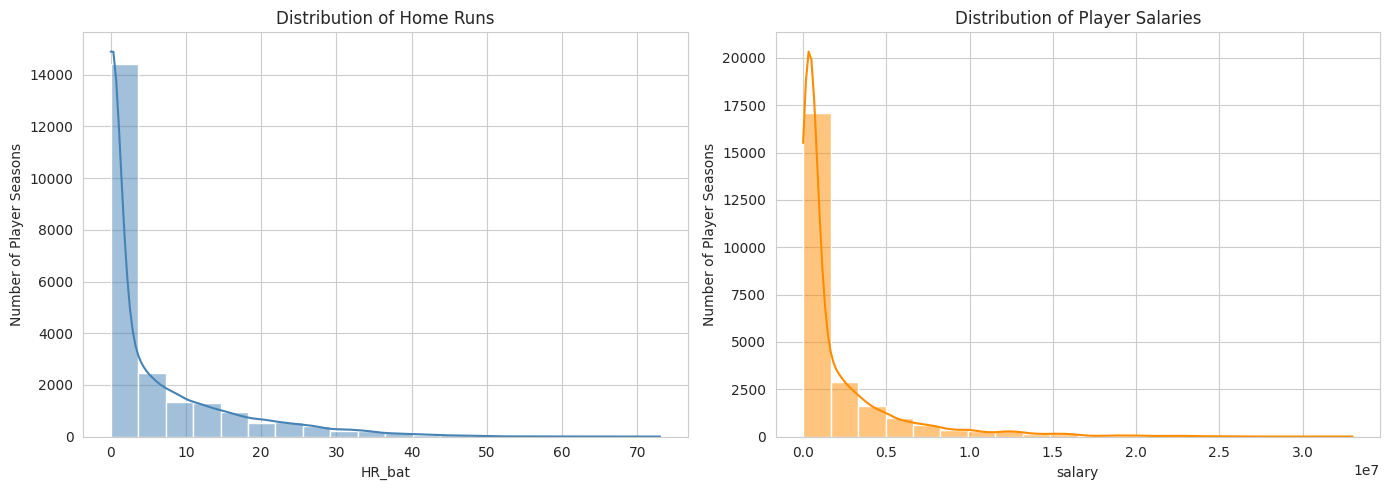

Salary distribution (labeled rows)
  Count          : 24,628
  Mean           : $2,035,611
  Median         : $560,000
  Std deviation  : $3,338,480
  Minimum        : $0
  Maximum        : $33,000,000
  Mean / median  : 3.64x
  Max / median   : 59x
  Std dev / mean : 1.64x
  Skewness       : 3.08


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features = ["HR_bat", "salary"]
titles = ["Distribution of Home Runs", "Distribution of Player Salaries"]
colors = ["steelblue", "darkorange"]

for ax, feature, title, color in zip(axes, features, titles, colors):
    sns.histplot(data=model_df.dropna(subset=[feature]), x=feature,
                 bins=20, kde=True, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Player Seasons")

plt.tight_layout()
plt.show()
sal = model_df["salary"]
print("Salary distribution (labeled rows)")
print(f"  Count          : {sal.count():,}")
print(f"  Mean           : ${sal.mean():,.0f}")
print(f"  Median         : ${sal.median():,.0f}")
print(f"  Std deviation  : ${sal.std():,.0f}")
print(f"  Minimum        : ${sal.min():,.0f}")
print(f"  Maximum        : ${sal.max():,.0f}")
print(f"  Mean / median  : {sal.mean() / sal.median():.2f}x")
print(f"  Max / median   : {sal.max() / sal.median():.0f}x")
print(f"  Std dev / mean : {sal.std() / sal.mean():.2f}x")
print(f"  Skewness       : {sal.skew():.2f}")

**Figure 1. Distributions of home runs and salary.** Histograms with kernel density
overlays for one representative performance feature and for the target variable.

The printed statistics quantify what the histogram shows qualitatively. The mean salary of
\$2,035,611 is 3.64x the median of \$560,000, the standard deviation exceeds the mean, and the maximum
sits at 59x the median. A skewness coefficient of 3.08 confirms the distribution is far from
symmetric. These are not a handful of stray outliers but a structurally heavy tail, and they
are the quantitative basis for Hypothesis 2.

Both distributions are strongly right-skewed and, notably, skewed in a very similar
shape. The bulk of player-seasons cluster near zero home runs and near the league minimum
salary, with a long thin tail of high-power hitters and high-earning stars. The skew in the
target is the basis of Hypothesis 2: a squared-error loss on raw dollars will be dominated by the handful of eight-figure contracts in the right tail.

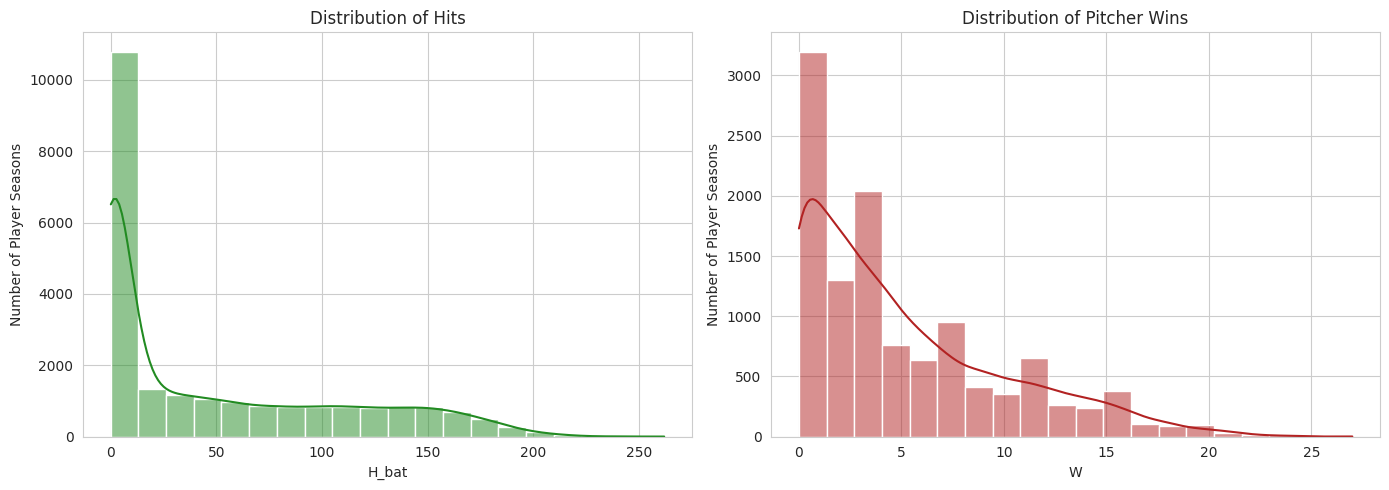

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features = ["H_bat", "W"]
titles = ["Distribution of Hits", "Distribution of Pitcher Wins"]
colors = ["forestgreen", "firebrick"]

for ax, feature, title, color in zip(axes, features, titles, colors):
    sns.histplot(data=model_df.dropna(subset=[feature]), x=feature,
                 bins=20, kde=True, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Player Seasons")

plt.tight_layout()
plt.show()

**Figure 2. Distributions of hits and pitcher wins.** The same treatment for a
volume-based batting statistic and a volume-based pitching statistic.

Both show the same right skew as Figure 1, which is the point: these are counting
statistics, so they are as much a measure of opportunity as of ability. A bench player and
a struggling starter both accumulate few hits, and a reliever accumulates few wins
regardless of quality. This means playing time is baked into most of our features, and it
raises the question of whether our models are learning "who is good" or "who plays", which we analyze  in Hypothesis 3.

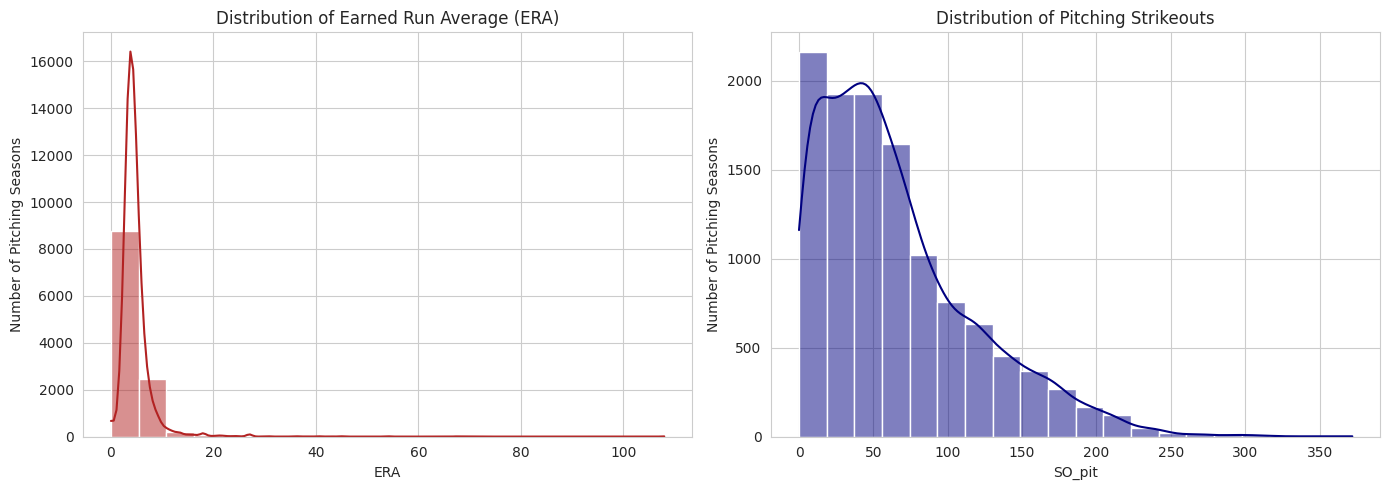

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features = ["ERA", "SO_pit"]
titles = ["Distribution of Earned Run Average (ERA)", "Distribution of Pitching Strikeouts"]
colors = ["firebrick", "navy"]

for ax, feature, title, color in zip(axes, features, titles, colors):
    sns.histplot(data=model_df.dropna(subset=[feature]), x=feature,
                 bins=20, kde=True, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Pitching Seasons")

plt.tight_layout()
plt.show()

**Figure 3. Distributions of `ERA` and pitching strikeouts.** Distributions restricted
to player-seasons with a pitching record.

The skew here is the most extreme in the dataset. `ERA` is bounded below by zero but
effectively unbounded above, and the tail is populated by pitchers with a handful of
innings. Taken with Figures 1 and 2, the consistent picture is that the vast majority of
player-seasons involve limited playing time and modest production, while a small number of
stars post large values across the board. Any model we fit will see far more of the former
than the latter, and we should expect its errors to concentrate on the stars.

### 2.4 Relationships with the target

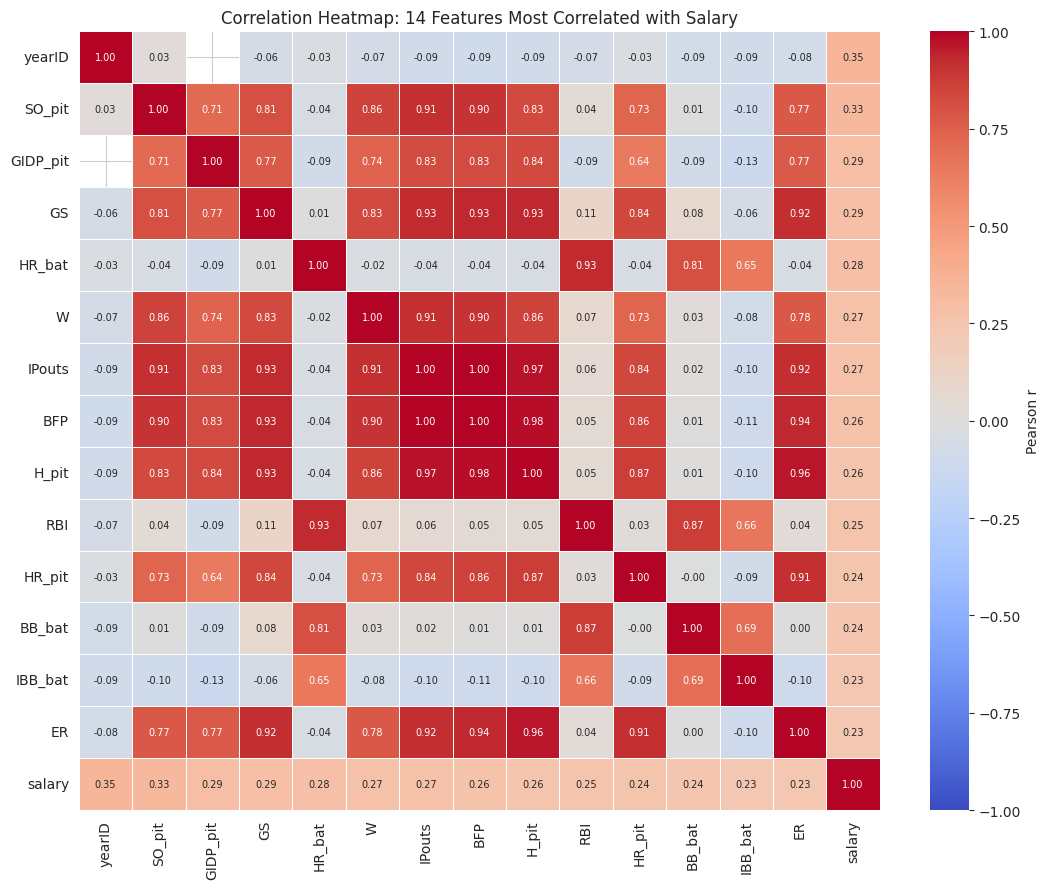

Top 14 features by |correlation| with salary:
yearID     0.35
SO_pit     0.33
GIDP_pit   0.29
GS         0.29
HR_bat     0.28
W          0.27
IPouts     0.27
BFP        0.26
H_pit      0.26
RBI        0.25
HR_pit     0.24
BB_bat     0.24
IBB_bat    0.23
ER         0.23


In [15]:
numeric = model_df.select_dtypes(include=[np.number]).drop(
    columns=["stint"], errors="ignore")

corr_rank = numeric.corr()["salary"].drop("salary").abs().sort_values(ascending=False)
top_features = corr_rank.head(14).index.tolist() + ["salary"]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(numeric[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={"size": 7}, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Heatmap: 14 Features Most Correlated with Salary")
plt.tight_layout()
plt.show()

print("Top 14 features by |correlation| with salary:")
print(corr_rank.head(14).round(3).to_string())

**Figure 4. Correlation heatmap of the features most associated with salary.** Pearson
correlations among the fourteen features with the strongest absolute correlation to
`salary`, plus the target itself. Correlations are computed pairwise on complete
observations, so pitching and batting features are each estimated on their own
sub-population.

**`yearID`, at
r = 0.35, is more correlated with salary than any performance statistic in the dataset.**
The best performance feature, `SO_pit`, reaches only 0.33, and nothing clears 0.35. No
individual feature is a strong linear predictor of salary — a caution both about what to
expect from linear models and about crediting any future R² to talent evaluation.

The third-ranked feature, `GIDP_pit` at 0.29, is an artifact and should be discarded:
Table 2 shows it is populated for only 386 of 24,628 labeled rows, so its correlation is
estimated on 1.6% of the data.

Among the predictors themselves, the redundancy is severe. `IPouts` and `BFP` correlate at
**1.00** to two decimal places — innings pitched and batters faced are the same quantity
measured twice. `BFP`–`H_pit` reaches 0.98, `IPouts`–`H_pit` 0.97, and `H_pit`–`ER` 0.96,
while `GS` correlates 0.92–0.93 with all of them. The batting side shows the same pattern
more mildly, with `HR_bat`–`RBI` at 0.93 and `RBI`–`BB_bat` at 0.87. Every one of these
pairs is a volume measure correlating with another volume measure, which is exactly the
redundancy Hypothesis 3 tests.

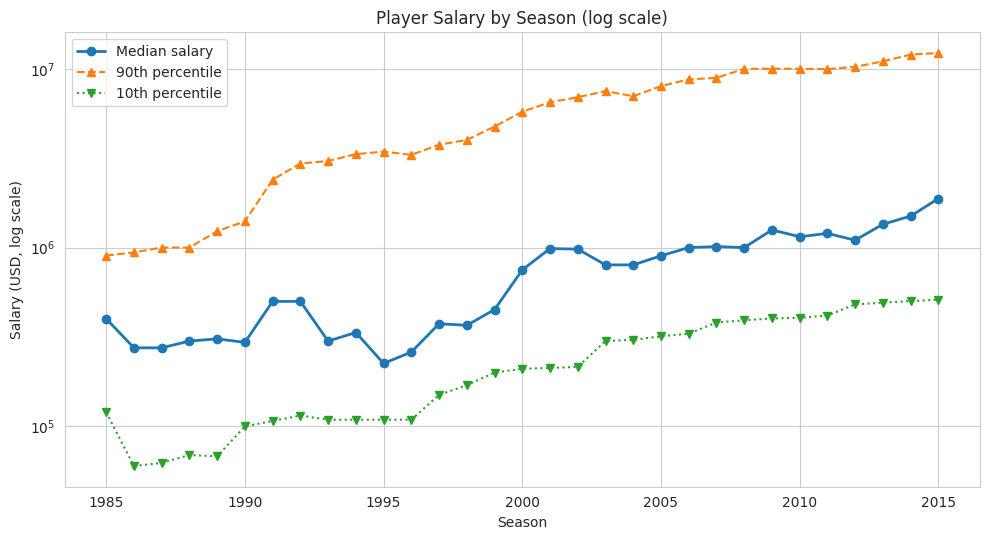

             Median           p90        p10
yearID                                      
1985     400,000.00    901,500.00 120,000.00
1986     275,000.00    939,933.00  60,000.00
1987     275,000.00  1,000,000.00  62,500.00
1988     300,000.00  1,000,000.00  69,200.00
1989     308,750.00  1,235,500.00  68,000.00
1990     295,000.00  1,400,000.00 100,000.00
1991     500,000.00  2,400,000.00 107,300.00
1992     500,000.00  2,950,000.00 115,000.00
1993     300,000.00  3,050,000.00 109,000.00
1994     335,000.00  3,331,666.00 109,000.00
1995     225,000.00  3,441,000.00 109,000.00
1996     260,416.00  3,300,000.00 109,000.00
1997     375,000.00  3,760,000.00 150,000.00
1998     367,500.00  4,000,000.00 170,000.00
1999     450,000.00  4,750,000.00 200,000.00
2000     750,000.00  5,750,000.00 210,000.00
2001     987,500.00  6,500,000.00 212,150.00
2002     980,000.00  6,930,441.00 215,300.00
2003     800,000.00  7,500,000.00 300,000.00
2004     800,000.00  7,020,000.00 305,000.00
2005     9

In [16]:
fig, ax = plt.subplots(figsize=(10, 5.5))

yearly = model_df.groupby("yearID")["salary"].agg(
    Median="median",
    p90=lambda s: s.quantile(0.90),
    p10=lambda s: s.quantile(0.10),
)

ax.plot(yearly.index, yearly["Median"], marker="o", lw=2, label="Median salary")
ax.plot(yearly.index, yearly["p90"], marker="^", lw=1.5, ls="--",
        label="90th percentile")
ax.plot(yearly.index, yearly["p10"], marker="v", lw=1.5, ls=":",
        label="10th percentile")
ax.set_yscale("log")
ax.set_title("Player Salary by Season (log scale)")
ax.set_xlabel("Season")
ax.set_ylabel("Salary (USD, log scale)")
ax.legend()
plt.tight_layout()
plt.show()

print(yearly.round(0).to_string())

**Figure 5. Salary by season, on a log scale.** Median, 10th percentile, and 90th
percentile of salary for each season in the labeled range, plotted on a log y-axis so that
proportional growth appears as a straight line.

This figure exposes that the same
performance earns very different pay depending on the year. The median salary rises
from \$400,000 in 1985 to \$1,880,000 in 2015 (4.7x), and the 90th percentile rises from
\$901,500 to \$12,250,000 (13.6x). Combined with Figure 4, where `yearID` is the
single most salary-correlated column in the dataset, this makes the season a confounder we
must handle explicitly rather than a neutral feature.

The growth is not proportional and the lines are not straight. The median is essentially
flat and noisy from 1985 through 1999, dipping as low as \$225,000 in 1995, before climbing
steadily thereafter — while the 90th percentile climbs steeply throughout the 1990s and
then flattens after roughly 2008. The consequence is a widening distribution: the ratio of
the 90th to the 10th percentile grows from about 7.5x in 1985 to about 24x in 2015. Salaries are fanning out, not just shifting upward, so a single global log transform
(Hypothesis 2) may not fully stabilize the variance.

The 10th-percentile line reveals something we did not anticipate. Its values repeat
*exactly* across consecutive seasons — \$109,000 in each of 1993, 1994, 1995 and 1996;
\$300,000 in 2003; \$200,000 in 1999 — and each printed value is suspiciously round. This is
the collectively bargained league minimum salary acting as a **hard lower bound on the
target that steps upward over time.** A large share of our rows are not market prices at
all but players pinned to that year's floor. Any model trained on raw dollars can and will
predict salaries below a floor that no player in that season could actually receive.

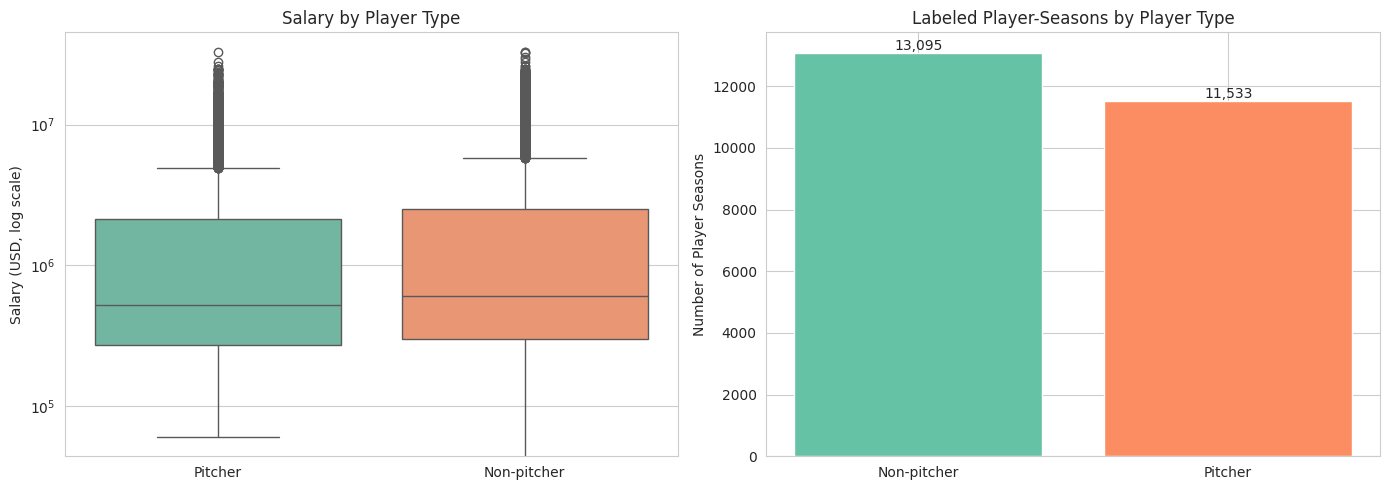

             Count     Median         Q1           Q3           Max
player_type                                                        
Non-pitcher  13095 600,000.00 300,000.00 2,500,000.00 33,000,000.00
Pitcher      11533 525,000.00 272,500.00 2,125,000.00 32,571,000.00


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=model_df, x="player_type", y="salary",
            hue="player_type", legend=False, palette="Set2", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Salary by Player Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Salary (USD, log scale)")

counts = model_df["player_type"].value_counts()
axes[1].bar(counts.index, counts.values, color=["#66c2a5", "#fc8d62"])
axes[1].set_title("Labeled Player-Seasons by Player Type")
axes[1].set_ylabel("Number of Player Seasons")
for i, v in enumerate(counts.values):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

summary_by_type = model_df.groupby("player_type")["salary"].agg(
    Count="count", Median="median",
    Q1=lambda s: s.quantile(0.25), Q3=lambda s: s.quantile(0.75),
    Max="max"
).round(0)
print(summary_by_type.to_string())

**Figure 6. Salary distribution and sample size by player type.** Left: box plots of salary
for pitchers and non-pitchers on a log scale. Right: the number of labeled player-seasons
in each group.

The two distributions are nearly indistinguishable. The medians sit within a hair of
each other at roughly \$500,000, the interquartile ranges overlap almost entirely, and both
groups show the same long upper tail of outliers past \$10 million. Non-pitchers have a
marginally higher upper quartile, but the difference is small relative to the spread.

Because player type produces almost no
shift in the target's level, a model gains essentially nothing from simply knowing whether
a player pitches. So, any benefit from training separate models must come entirely
from the feature structure rather than from a difference in the outcome.

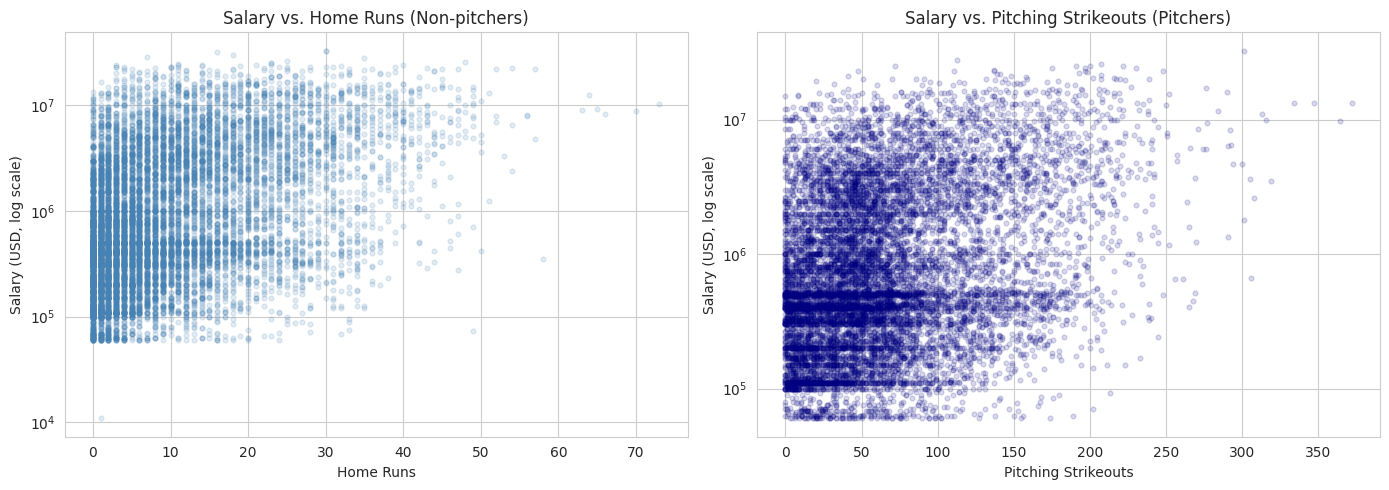

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pairs = [("HR_bat", "Home Runs", "Non-pitcher"), ("SO_pit", "Pitching Strikeouts", "Pitcher")]
colors = ["steelblue", "navy"]

for ax, (feature, label, group), color in zip(axes, pairs, colors):
    subset = model_df[(model_df["player_type"] == group)].dropna(subset=[feature, "salary"])
    ax.scatter(subset[feature], subset["salary"], alpha=0.15, s=12, color=color)
    ax.set_yscale("log")
    ax.set_title(f"Salary vs. {label} ({group}s)")
    ax.set_xlabel(label)
    ax.set_ylabel("Salary (USD, log scale)")

plt.tight_layout()
plt.show()

**Figure 7. Salary against a key performance statistic for each player type.** Scatter
plots of salary versus home runs for non-pitchers and versus strikeouts for pitchers, both
with a log salary axis and transparency to show density.

The wedge pattern appears in both panels, and more cleanly on the pitching side. At low
production values the salary cloud spans from the league
minimum to well past \$10 million. As production rises, the bottom of the cloud lifts and
the low-salary points disappear entirely, while the top edge stays roughly flat. High
production is therefore close to sufficient for high pay, but low production is not
sufficient for low pay because that group mixes replacement-level veterans with
pre-arbitration rookies, injured stars, and September call-ups who simply had no
opportunity to accumulate totals.

Two further features are visible. First, a flat lower boundary runs along the bottom of
both clouds at every production level, which is the year-varying salary floor identified in
Figure 5 rather than anything to do with performance. Second, the clearest outliers are
high-production seasons paid near that floor — visible in the left panel as points far
to the right sitting at roughly \$10^5. These are almost certainly players still on rookie
contracts, who are highly productive but not yet eligible for arbitration, and they are a
population no performance-only model can price correctly.

The modeling implication is that the relationship is one-sided and strongly
heteroscedastic: the variance in salary is large at low production and shrinks as
production rises.

## 3. Hypotheses / Research Questions


### Hypothesis 1

**Statement.** Two separate models, one for pitchers and one for non-pitchers, will predict
salary better than a single model trained on all players with imputed values.

**Supporting evidence.** **Table 2** shows that missingness in this dataset is structural rather than random: the pitching features are absent
for essentially every non-pitcher and the batting features are largely absent for pitchers. **Figure 6** shows that the two groups are
nonetheless comparable in size and both map to the same target, and **Tables 3 and 4** show that the two feature sets are measured on
entirely different scales and units. Filling these gaps with a column mean would assert that a catcher posted a league-average `ERA`, which
is not a missing measurement but a fabricated one.

**Why is this interesting.** Pitchers and hitters are paid for different things, and a player
only needs to be good at one to earn well. A pooled model has to work out which role it is
looking at from the missingness pattern before it can use anything else. Imputing across
roles is worse than leaving the gaps, since it invents performances that never happened.

**How we will evaluate it.** We will train a pooled model with median imputation and
missingness indicators, plus one model each on the pitcher and non-pitcher subsets. On a
single train/test split stratified by player type, we will compare RMSE and MAE, weighting
the two specialist models by group size so both approaches are scored on the same rows. We
will report error per group as well, since splitting may help one and hurt the other, and we
will run the comparison on a linear model and a gradient-boosted tree. We expect the linear
model to gain more, since trees handle missing values on their own.

---

### Hypothesis 2

**Statement.** Log-transforming salary will yield better predictive performance.

**Supporting evidence.** The right panel of **Figure 1** shows that salary is heavily
right-skewed: the mean exceeds the median by a factor of 3.64, the standard deviation is
larger than the mean itself, and the maximum sits at 59x the median.

**Why is this interesting.** Squared-error loss on a skewed target is dominated by the
largest values, so a model can minimize training loss by fitting a few superstars well and
treating the majority of players as noise. A log transform converts the objective from
absolute dollar error to roughly proportional error, which also matches how salaries are
actually discussed — the meaningful difference between a \$500k and a \$5M player is a
multiple, not a difference.

**How we will evaluate it.** We will train identical models on `salary` and on `log(salary)`. Critically, error metrics
computed in log space are not comparable to error metrics computed in dollars, so we will
exponentiate the log-model's predictions back to dollars before scoring and evaluate both
models with RMSE and MAE on the same dollar scale. We will also report median absolute
percentage error and inspect residuals against predicted salary to check whether the
transform fixes the heteroscedasticity we expect in the raw-target model.

---

### Hypothesis 3

**Statement.** A playing-time measure plus the season year will match the predictive performance of the full feature set, because most of our features
are collinear proxies for opportunity rather than independent signals of ability.

**Supporting evidence.** **Figure 4** shows a dense block of mutually correlated counting
statistics, all of which scale with playing time, and shows `yearID` among the features
most correlated with the target. **Figure 5** explains why: salaries rise by orders of
magnitude across the labeled period, so the season alone carries substantial information
about the target without describing the player at all. **Figure 2** shows that the counting
statistics measure opportunity as much as skill, since a bench player and a poor starter
both accumulate small totals.

**Why is this interesting.** If true, it means an impressive-looking R² on this dataset is
largely inflation and playing time rather than talent evaluation, which is a caution about
how we report results. If false and the full feature set clearly
beats the reduced one, then the performance statistics carry genuine independent signal,
which is the more interesting outcome.

**How we will evaluate it.** We will compare a baseline using only `yearID` and a
playing-time proxy (`G_bat` or `IPouts`) against the full-feature model, using the same
split and metrics. We will then run permutation importance on the full model and inspect
whether the top-ranked features are volume measures or rate measures. Finally, we will
check variance inflation factors across the counting statistics to quantify the
multicollinearity visible in Figure 4, and re-fit after dropping the most inflated columns
to confirm performance is unaffected.

### Hypothesis 4

**Statement.** Home runs are a weak and unreliable individual predictor of salary when
pitchers and low-playing-time seasons are pooled together, and their predictive power will
increase once the roles are separated.

**Supporting evidence.** The left panel of **Figure 7** shows that at low home-run totals
salary spans nearly the full range, so home runs alone do not separate high earners from
low ones. **Figure 6** shows pitchers and non-pitchers earn comparable salaries despite
pitchers producing almost no home runs, meaning a pooled home-run column mixes two
populations for whom the statistic means entirely different things.

**Why is this interesting.** It pushes back on the intuitive assumption that more home runs
means more pay, and it shows the apparent weakness of a feature can be an artifact of
pooling rather than a property of the feature.

**How we evaluated it.** We built two datasets from the labeled player-season frame: a pooled version (all players) and a non-pitcher-only version, using `HR_bat`, `G_bat`, and `AB` as features (`yearID` was excluded to avoid conflating this test with the salary-inflation effect examined in Hypothesis 3). Missing values in these three batting columns were filled with 0 rather than a summary statistic, since a pitcher with no recorded at-bats actually had zero batting opportunities rather than an unmeasured one. We tested `HR_bat`'s relationship to salary three ways: a univariate Pearson correlation, a standardized linear regression coefficient, and Random Forest feature importance.

## 4. Data Preparation

The cell below builds the feature matrix and the train/test split that every experiment in Section 6 uses.

The tree models can handle `NaN` on their own, so they get the raw data. Linear regression cannot, so it gets median imputation plus a flag column marking which values were filled in. The flags matter because the gaps are structural (Table 2), not random.

We drop `GIDP_pit` completely since it only exists for 386 rows. The split is a single 80/20 split, stratified by player type, and every experiment uses the same one. We also build a `games` column for Hypothesis 3 by filling `G_bat` with `G_pit` so every row has a playing time value.

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42

NON_FEATURES = ["playerID", "teamID", "lgID", "stint", "salary", "player_type"]
DROP_COLS = ["GIDP_pit"]

numeric_cols = model_df.select_dtypes(include=[np.number]).columns.tolist()
FEATURES = [c for c in numeric_cols if c not in NON_FEATURES and c not in DROP_COLS]

X = model_df[FEATURES]
y = model_df["salary"]
group = model_df["player_type"]

X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, group, test_size=0.2, random_state=RANDOM_STATE, stratify=group
)

print(f"Features            : {len(FEATURES)}")
print(f"Train / test rows   : {len(X_train):,} / {len(X_test):,}")
print(f"Test pitchers       : {(g_test == 'Pitcher').sum():,}")
print(f"Test non-pitchers   : {(g_test == 'Non-pitcher').sum():,}")
print(f"Columns with any NaN: {(X.isna().sum() > 0).sum()} of {len(FEATURES)}")

Features            : 42
Train / test rows   : 19,702 / 4,926
Test pitchers       : 2,307
Test non-pitchers   : 2,619
Columns with any NaN: 40 of 42


## 5. Models & Experimental Design

We use linear regression as a baseline plus two tree models: random forest and gradient boosted trees. The tree models handle missing values natively and linear regression cannot, which is the contrast Hypothesis 1 needs. The two tree models get a small grid search on the training split and the winning settings are reused everywhere.

Metrics are RMSE and MAE in dollars, plus median absolute percentage error. MedAPE is there because the salary tail is huge (Figure 1) and we wanted one metric that is not dominated by the superstar contracts.

Each experiment tests one hypothesis: pooled vs split is H1, raw vs log target is H2, the feature ladder plus permutation importance and VIF is H3, and the role separated importance comparison is H4.

In [20]:
def make_linear():
    """Linear regression cannot take NaN, so it gets median imputation + missingness flags."""
    return Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
        ("model", LinearRegression()),
    ])


def make_rf(**p):
    params = dict(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    params.update(p)
    return RandomForestRegressor(**params)


def make_hgb(**p):
    params = dict(random_state=RANDOM_STATE)
    params.update(p)
    return HistGradientBoostingRegressor(**params)


def score(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ape = np.abs(y_pred - y_true) / np.maximum(y_true, 1)
    return {
        "Approach": label,
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "MedAPE %": 100 * np.median(ape),
    }

In [21]:
rf_grid = {
    "n_estimators": [100],
    "min_samples_leaf": [5, 20],
    "max_features": ["sqrt", 0.5],
}
hgb_grid = {
    "max_iter": [300],
    "learning_rate": [0.06, 0.1],
    "max_leaf_nodes": [31, 63],
}

best_params = {}
for name, estimator, grid in [("RandomForest", make_rf(), rf_grid),
                              ("HistGradientBoosting", make_hgb(), hgb_grid)]:
    search = GridSearchCV(
        estimator, grid, cv=3,
        scoring="neg_root_mean_squared_error", n_jobs=-1,
    )
    search.fit(X_train, y_train)
    best_params[name] = search.best_params_
    print(f"{name:>22} | CV RMSE {-search.best_score_:>12,.0f} | {search.best_params_}")

print("\nLinearRegression has no hyperparameters to tune.")

          RandomForest | CV RMSE    2,588,427 | {'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 100}
  HistGradientBoosting | CV RMSE    2,598,803 | {'learning_rate': 0.06, 'max_iter': 300, 'max_leaf_nodes': 31}

LinearRegression has no hyperparameters to tune.


## 6. Results & Hypothesis Evaluation

### 6.1 Hypothesis 1: pooled model vs separate models

One pooled model on all rows, then one model per role, with predictions recombined so both are scored on the same test rows.

In [22]:
builders = {
    "LinearRegression": make_linear,
    "RandomForest": lambda: make_rf(**best_params["RandomForest"]),
    "HistGradientBoosting": lambda: make_hgb(**best_params["HistGradientBoosting"]),
}

overall_rows, group_rows = [], []

for name, build in builders.items():
    # Model A: one pooled model on every player-season
    pooled = build()
    pooled.fit(X_train, y_train)
    pooled_pred = pooled.predict(X_test)
    overall_rows.append(score(y_test, pooled_pred, f"{name} — pooled"))

    # Models B: one model per role, predictions recombined onto the same test rows
    split_pred = np.empty(len(y_test))
    for grp in ["Pitcher", "Non-pitcher"]:
        tr_mask, te_mask = (g_train == grp), (g_test == grp)
        X_grp = X_train[tr_mask]
        # Keep only columns that actually exist for this role (>1% populated)
        keep = X_grp.columns[X_grp.notna().mean() > 0.01].tolist()

        specialist = build()
        specialist.fit(X_grp[keep], y_train[tr_mask])
        grp_pred = specialist.predict(X_test.loc[te_mask, keep])
        split_pred[te_mask.values] = grp_pred

        p = score(y_test[te_mask], pooled_pred[te_mask.values], f"{name} — pooled [{grp}]")
        s = score(y_test[te_mask], grp_pred, f"{name} — split  [{grp}]")
        p["Features"], s["Features"] = len(FEATURES), len(keep)
        group_rows += [p, s]

    overall_rows.append(score(y_test, split_pred, f"{name} — split"))

overall = pd.DataFrame(overall_rows)
by_group = pd.DataFrame(group_rows)

print("OVERALL (all test rows)")
print(overall.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))
print("\nBY PLAYER TYPE")
print(by_group.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

OVERALL (all test rows)
                     Approach          RMSE           MAE    R2  MedAPE %
    LinearRegression — pooled 2,840,081.378 1,792,996.346 0.338   136.602
     LinearRegression — split 2,835,248.142 1,791,906.369 0.340   136.165
        RandomForest — pooled 2,654,723.907 1,547,413.607 0.422    79.827
         RandomForest — split 2,646,968.360 1,540,779.838 0.425    79.005
HistGradientBoosting — pooled 2,676,734.040 1,563,085.008 0.412    93.870
 HistGradientBoosting — split 2,657,122.472 1,525,929.740 0.421    81.268

BY PLAYER TYPE
                                   Approach          RMSE           MAE    R2  MedAPE %  Features
        LinearRegression — pooled [Pitcher] 2,563,917.365 1,654,545.917 0.301   137.084        42
        LinearRegression — split  [Pitcher] 2,557,964.285 1,639,292.645 0.304   132.994        42
    LinearRegression — pooled [Non-pitcher] 3,062,787.069 1,914,953.253 0.355   136.281        42
    LinearRegression — split  [Non-pitcher] 3,058,

**Table 5. Hypothesis 1 metrics, pooled vs split.** Overall scores on all test rows, then the same comparison within each player type. The two specialist models are recombined so both approaches are scored on the same rows.

               Model  RMSE pooled   RMSE split  RMSE gain %   MAE pooled    MAE split  MAE gain %
    LinearRegression 2,840,081.38 2,835,248.14         0.17 1,792,996.35 1,791,906.37        0.06
        RandomForest 2,654,723.91 2,646,968.36         0.29 1,547,413.61 1,540,779.84        0.43
HistGradientBoosting 2,676,734.04 2,657,122.47         0.73 1,563,085.01 1,525,929.74        2.38


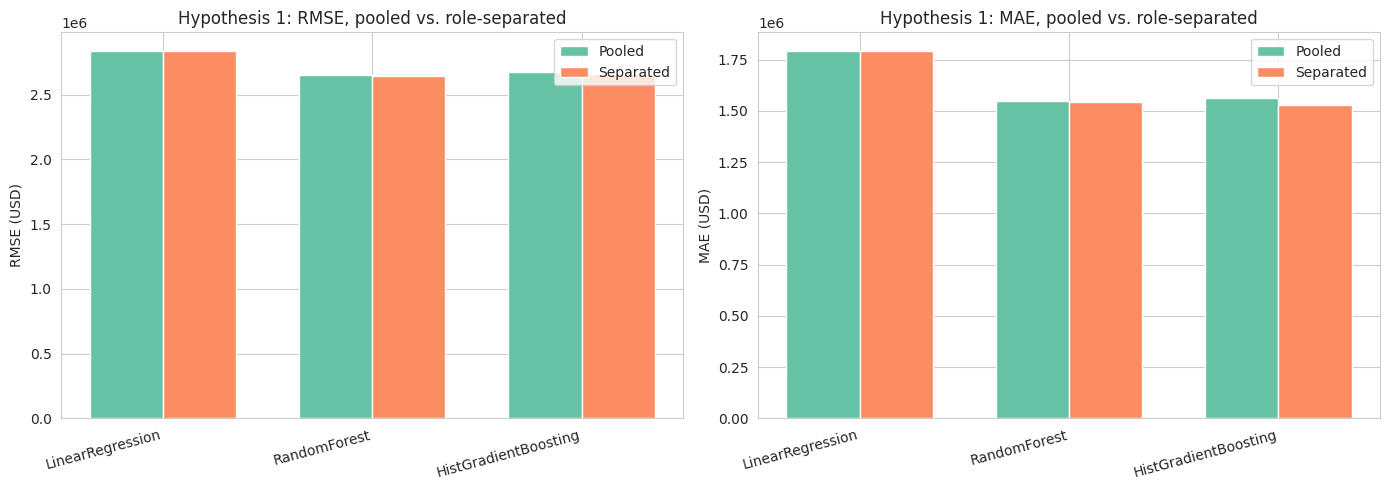

In [23]:
gain = []
for name in builders:
    p = overall.loc[overall["Approach"] == f"{name} — pooled"].iloc[0]
    s = overall.loc[overall["Approach"] == f"{name} — split"].iloc[0]
    gain.append({
        "Model": name,
        "RMSE pooled": p["RMSE"], "RMSE split": s["RMSE"],
        "RMSE gain %": 100 * (p["RMSE"] - s["RMSE"]) / p["RMSE"],
        "MAE pooled": p["MAE"], "MAE split": s["MAE"],
        "MAE gain %": 100 * (p["MAE"] - s["MAE"]) / p["MAE"],
    })

gain_df = pd.DataFrame(gain)
print(gain_df.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
idx = np.arange(len(gain_df))
w = 0.35

for ax, metric in zip(axes, ["RMSE", "MAE"]):
    ax.bar(idx - w/2, gain_df[f"{metric} pooled"], w, label="Pooled", color="#66c2a5")
    ax.bar(idx + w/2, gain_df[f"{metric} split"], w, label="Separated", color="#fc8d62")
    ax.set_xticks(idx)
    ax.set_xticklabels(gain_df["Model"], rotation=15, ha="right")
    ax.set_ylabel(f"{metric} (USD)")
    ax.set_title(f"Hypothesis 1: {metric}, pooled vs. role-separated")
    ax.legend()

plt.tight_layout()
plt.show()

**Table 6 and Figure 8. Gains from splitting by role.** Percent change in RMSE and MAE when moving from the pooled model to the role-separated pair, shown as a table and as bars. Positive means splitting helped.

**Verdict on Hypothesis 1:** Not supported. Splitting by role barely moved anything (Tables 5 and 6, Figure 8): RMSE gains were 0.2% for linear regression, 0.3% for random forest, and 0.7% for boosted trees. We also predicted the linear model would gain the most and that did not happen. The per-group rows of Table 5 are nearly identical for both approaches. The models already deal with the missing values on their own, so the split was not needed.

### 6.2 Hypothesis 2: raw dollars vs log dollars

Same split. One copy of the model trained on dollars and one on log dollars, with the log predictions converted back to dollars before scoring.

In [24]:
LOG, INV = np.log1p, np.expm1

builders_h2 = {"LinearRegression": make_linear}

log_rows, predictions = [], {}

for name, build in builders_h2.items():
    raw = build()
    raw.fit(X_train, y_train)
    pred_raw = raw.predict(X_test)
    log_rows.append(score(y_test, pred_raw, f"{name} — raw dollars"))

    logm = build()
    logm.fit(X_train, LOG(y_train))
    pred_log_dollars = INV(logm.predict(X_test))
    log_rows.append(score(y_test, pred_log_dollars, f"{name} — log target"))

    predictions[name] = {"raw dollars": pred_raw, "log target": pred_log_dollars}

h2 = pd.DataFrame(log_rows)
print("ALL SCORED IN DOLLARS (log predictions exponentiated back)")
print(h2.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

ALL SCORED IN DOLLARS (log predictions exponentiated back)
                      Approach          RMSE           MAE    R2  MedAPE %
LinearRegression — raw dollars 2,840,081.378 1,792,996.346 0.338   136.602
 LinearRegression — log target 3,050,184.277 1,522,648.032 0.236    73.136


**Table 7. Hypothesis 2, raw target vs log target.** Both rows are scored in dollars, with the log model's predictions exponentiated back before scoring.

**Verdict on Hypothesis 2:** Yes, with a tradeoff (Table 7). RMSE got worse (\$2.84M to \$3.05M) but MAE improved (\$1.79M to \$1.52M) and MedAPE dropped from 137% to 73%. The log model is better for the typical player and worse on the superstar contracts, which is what dominates RMSE. Given the choice we would keep the log model: halving the median percentage error matters for most players, and the superstar contracts it prices worse are the ones least explainable from season statistics in the first place.

### 6.3 Hypothesis 3: year plus playing time vs the full feature set

Three parts. A ladder of models: `yearID` alone, then `yearID` plus one playing time column, then everything. Then permutation importance on the full model. Then VIF on the counting stats and a refit without the redundant columns.

The playing time column is `games`, which is `G_bat` filled with `G_pit` so every row has a value.

                               Approach          RMSE           MAE    R2  MedAPE %  Features
         LinearRegression — yearID only 3,262,123.174 2,062,336.823 0.127   139.064         1
     HistGradientBoosting — yearID only 3,258,296.329 2,040,119.962 0.129   166.460         1
      LinearRegression — yearID + games 3,196,660.824 2,008,580.822 0.161   158.191         2
  HistGradientBoosting — yearID + games 3,148,113.360 1,912,913.093 0.187   134.058         2
    LinearRegression — full feature set 2,840,081.378 1,792,996.346 0.338   136.602        42
HistGradientBoosting — full feature set 2,676,734.040 1,563,085.008 0.412    93.870        42


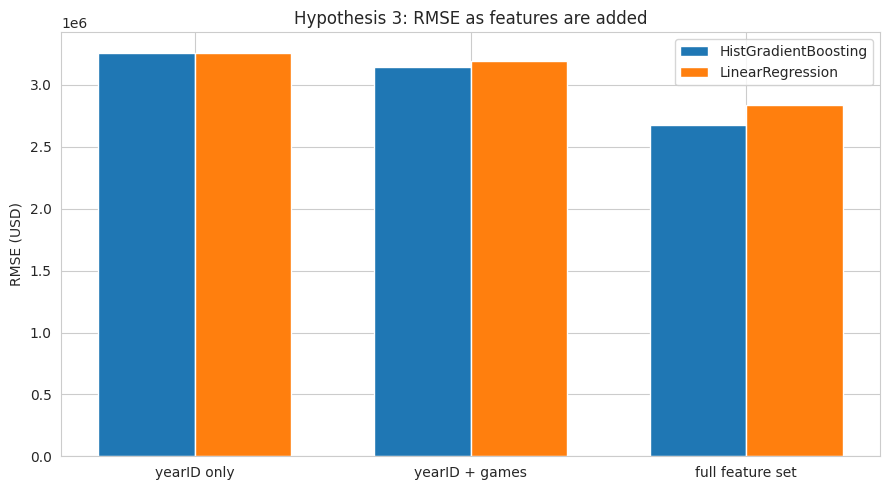

In [25]:
games = model_df["G_bat"].fillna(model_df["G_pit"]).rename("games")

h3_sets = {
    "yearID only": model_df[["yearID"]],
    "yearID + games": pd.concat([model_df[["yearID"]], games], axis=1),
    "full feature set": X,
}

h3_models = {
    "LinearRegression": make_linear,
    "HistGradientBoosting": lambda: make_hgb(**best_params["HistGradientBoosting"]),
}

h3_rows, h3_fitted = [], {}
for set_name, X_h3 in h3_sets.items():
    X_tr, X_te = X_h3.loc[X_train.index], X_h3.loc[X_test.index]
    for model_name, build in h3_models.items():
        m = build()
        m.fit(X_tr, y_train)
        row = score(y_test, m.predict(X_te), f"{model_name} — {set_name}")
        row["Features"] = X_h3.shape[1]
        h3_rows.append(row)
        h3_fitted[(model_name, set_name)] = m

h3_ladder = pd.DataFrame(h3_rows)
print(h3_ladder.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

piv = h3_ladder.copy()
piv["Model"] = piv["Approach"].str.split(" — ").str[0]
piv["Set"] = piv["Approach"].str.split(" — ").str[1]
piv = piv.pivot(index="Set", columns="Model", values="RMSE").loc[list(h3_sets)]

fig, ax = plt.subplots(figsize=(9, 5))
idx = np.arange(len(piv))
w = 0.35
for k, model_name in enumerate(piv.columns):
    ax.bar(idx + (k - 0.5) * w, piv[model_name], w, label=model_name)
ax.set_xticks(idx)
ax.set_xticklabels(piv.index)
ax.set_ylabel("RMSE (USD)")
ax.set_title("Hypothesis 3: RMSE as features are added")
ax.legend()
plt.tight_layout()
plt.show()

**Table 8 and Figure 9. Hypothesis 3 feature ladder.** RMSE as the feature set grows from `yearID` alone to the full set, for both model families.

Table 8 and Figure 9 show RMSE dropping from `yearID` + `games` to the full set. The two feature model lands at \$3,148,113 against \$2,676,734 for the full set, so the full set is about 15% better. Two features still get an R² of 0.19 vs 0.41 for all 42 columns, so a lot of the signal is year and playing time.

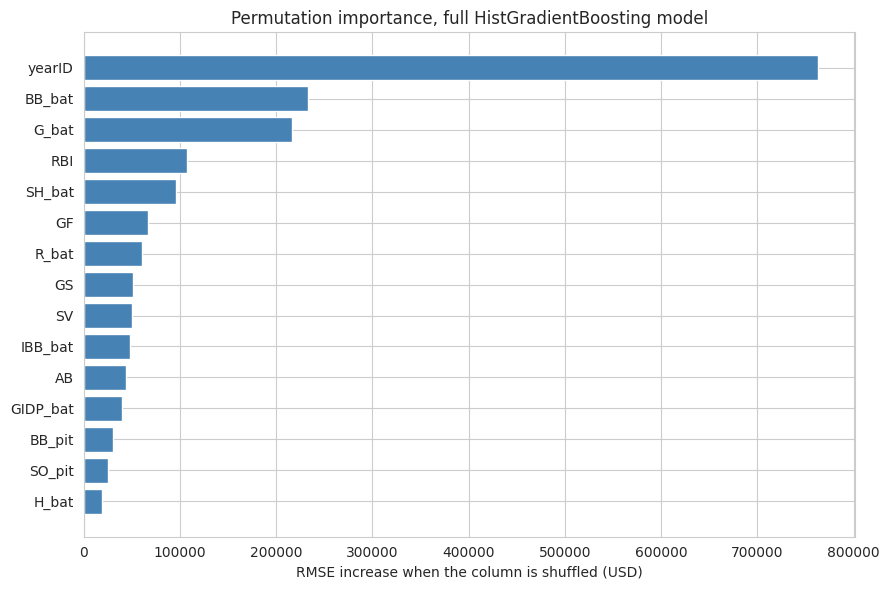

yearID     762,993.00
BB_bat     233,398.00
G_bat      216,330.00
RBI        107,066.00
SH_bat      95,679.00
GF          67,091.00
R_bat       60,325.00
GS          51,483.00
SV          50,607.00
IBB_bat     48,194.00
AB          44,382.00
GIDP_bat    39,442.00
BB_pit      30,913.00
SO_pit      25,416.00
H_bat       18,958.00


In [26]:
from sklearn.inspection import permutation_importance

full_hgb = h3_fitted[("HistGradientBoosting", "full feature set")]

perm = permutation_importance(
    full_hgb, X_test, y_test,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)

imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()
top15 = imp.tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15.index, top15.values, color="steelblue")
ax.set_xlabel("RMSE increase when the column is shuffled (USD)")
ax.set_title("Permutation importance, full HistGradientBoosting model")
plt.tight_layout()
plt.show()

print(top15.iloc[::-1].round(0).to_string())

**Figure 10. Permutation importance for the full boosted tree model.** Bar length is the RMSE increase, in dollars, when that column is shuffled on the test set. The printed list repeats the top values.

Top three (Figure 10) are `yearID`, `BB_bat`, and `G_bat`. `yearID` is worth about \$763,000 of RMSE on its own, over 3x the next column. Nothing rate based like `ERA` is anywhere near the top.

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

count_cols = ["G_bat", "AB", "R_bat", "H_bat", "2B", "3B", "HR_bat", "RBI", "SB",
              "BB_bat", "SO_bat", "G_pit", "GS", "IPouts", "H_pit", "ER",
              "HR_pit", "BB_pit", "SO_pit", "BFP", "W", "L"]
count_cols = [c for c in count_cols if c in X_train.columns]

vif_X = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X_train[count_cols]),
    columns=count_cols,
)
vif_X.insert(0, "const", 1.0)

def vif_table(df):
    return pd.Series(
        [variance_inflation_factor(df.values, i) for i in range(1, df.shape[1])],
        index=df.columns[1:],
    ).sort_values(ascending=False)

print("VIF before pruning")
print(vif_table(vif_X).round(1).to_string())

dropped = []
while True:
    v = vif_table(vif_X)
    if v.iloc[0] <= 10 or len(v) <= 2:
        break
    dropped.append(v.index[0])
    vif_X = vif_X.drop(columns=[v.index[0]])

print(f"\nDropped {len(dropped)} columns, in order: {dropped}")
print("\nVIF after pruning")
print(vif_table(vif_X).round(1).to_string())

VIF before pruning
BFP      3,952.50
IPouts   2,027.70
H_pit      244.10
H_bat      115.90
AB         109.90
R_bat       43.60
ER          42.20
RBI         32.40
BB_pit      26.20
GS          17.50
G_bat       17.00
HR_bat      14.00
2B          13.80
SO_pit       9.30
SO_bat       8.60
W            7.30
BB_bat       6.90
HR_pit       6.90
L            5.30
G_pit        4.60
SB           2.60
3B           2.50

Dropped 9 columns, in order: ['BFP', 'H_bat', 'IPouts', 'AB', 'H_pit', 'R_bat', 'RBI', 'ER', 'GS']

VIF after pruning
G_bat    9.30
2B       7.20
SO_bat   5.70
SO_pit   5.20
BB_bat   5.20
W        4.30
HR_bat   4.30
BB_pit   4.00
L        3.60
HR_pit   3.60
3B       2.20
G_pit    2.00
SB       1.90


**Table 9. Variance inflation factors before and after pruning.** Columns are removed greedily until the largest VIF falls to 10 or below; the dropped columns are listed in order.

In [28]:
FEATURES_pruned = [c for c in FEATURES if c not in dropped]

refit_rows = []
for model_name, build in h3_models.items():
    m = build()
    m.fit(X_train[FEATURES_pruned], y_train)
    row = score(y_test, m.predict(X_test[FEATURES_pruned]),
                f"{model_name} — after VIF pruning")
    row["Features"] = len(FEATURES_pruned)
    refit_rows.append(row)

h3_refit = pd.DataFrame(refit_rows)
print(h3_refit.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))
print(f"\nFull set: {len(FEATURES)} features. Pruned set: {len(FEATURES_pruned)}.")

                                Approach          RMSE           MAE    R2  MedAPE %  Features
    LinearRegression — after VIF pruning 2,864,423.807 1,798,112.161 0.327   137.021        33
HistGradientBoosting — after VIF pruning 2,722,410.055 1,585,442.188 0.392    91.540        33

Full set: 42 features. Pruned set: 33.


**Table 10. Performance after VIF pruning.** The same models refit on the pruned feature set, for comparison against the full-set rows of Table 8.

A VIF above 10 is the usual line for a collinearity problem, and the before table (Table 9) is way past it. Nine columns got dropped (`BFP`, `H_bat`, `IPouts`, `AB`, `H_pit`, `R_bat`, `RBI`, `ER`, `GS`), all volume stats. After pruning (Table 10), RMSE barely moved: \$2,676,734 to \$2,722,410 for the boosted trees and under 1% for linear. So those nine columns were mostly redundant.

**Verdict on Hypothesis 3:** Not supported as stated. The full set beats the two feature baseline by about 15%, so the stats do carry real signal. The redundancy part holds up, however. `yearID` is the top feature by 3x, the next ones are all volume stats, and nine columns can be dropped for under a 2% cost.

### 6.4 Hypothesis 4: home run importance once roles are separated

This block builds its own frames from `model_df` so it can run on its own without the shared split above.

In [29]:
from sklearn.model_selection import train_test_split

# --- create a copy to have modeling be self contained
h4_df = model_df.copy()

# --- utilizing 3 main features for hitting and filling anything with NaN with 0s
batting_cols = ["HR_bat", "G_bat", "AB"]
h4_df[batting_cols] = h4_df[batting_cols].fillna(0)

# --- create seperates pools for modeling
h4_features = ["HR_bat", "G_bat", "AB"]
pooled_df = h4_df[h4_features + ["salary"]].copy()
non_pitcher_df = h4_df.loc[h4_df["player_type"] == "Non-pitcher", h4_features + ["salary"]].copy()

print(f"Pooled dataset:       {pooled_df.shape[0]:,} rows")
print(f"Non-pitcher dataset:  {non_pitcher_df.shape[0]:,} rows")

# --- Independent train/test splits
X_pooled, y_pooled = pooled_df[h4_features], pooled_df["salary"]
X_pooled_train, X_pooled_test, y_pooled_train, y_pooled_test = train_test_split(
    X_pooled, y_pooled, test_size=0.2, random_state=42
)

X_np, y_np = non_pitcher_df[h4_features], non_pitcher_df["salary"]
X_np_train, X_np_test, y_np_train, y_np_test = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42
)

Pooled dataset:       24,628 rows
Non-pitcher dataset:  13,095 rows


- Going to utilize 3 main features that is HR + 2 (`G_bat` and `AB`)

- Filling anything in those columns that has `NaN` with 0s.
Example: A traded pitcher who logged an at-bat in an NL game and a pitcher who never batted at all are both "0 home runs," not missing data.

- trained with a 80/20 split across both pools of data using a random_state=42

| Dataset | Rows |
|---|---|
| `Pooled` | 24,628 |
| `Non-Pitcher` | 13,095 |

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# --- for pooled_df we fit scaler on train, transform both
pooled_scaler = StandardScaler()
X_pooled_train_scaled = pooled_scaler.fit_transform(X_pooled_train)
X_pooled_test_scaled = pooled_scaler.transform(X_pooled_test)

# --- for non_pitcher_df we do same as above but on its own data, fit scaler on train and transform both
np_scaler = StandardScaler()
X_np_train_scaled = np_scaler.fit_transform(X_np_train)
X_np_test_scaled = np_scaler.transform(X_np_test)

# --- Fit LinearRegression on each
lr_pooled = LinearRegression()
lr_pooled.fit(X_pooled_train_scaled, y_pooled_train)

lr_np = LinearRegression()
lr_np.fit(X_np_train_scaled, y_np_train)

# --- Compare HR_bat's coefficient between the two models
coef_compare = pd.DataFrame({
    "Feature": h4_features,
    "Coefficient (Pooled)": lr_pooled.coef_,
    "Coefficient (Non-pitcher only)": lr_np.coef_,
})
print(coef_compare.to_string(index=False))

Feature  Coefficient (Pooled)  Coefficient (Non-pitcher only)
 HR_bat          1,026,977.37                    1,107,533.89
  G_bat           -644,615.68                   -1,746,852.17
     AB            520,074.08                    2,095,330.37


**Table 11. Standardized linear regression coefficients, pooled vs non-pitcher.** `HR_bat` did move in the right direction but only by 8%, not the dramatic jump we were looking for.

The other two features, `G_bat` and `AB`, both measure batting playing time in different ways. `G_bat`'s coefficient is negative, which does not make sense: more games played should mean more pay, not less. The same wide swing in `AB` shows the model having a hard time deciding which of the two collinear columns should get the credit.

In [31]:
# --- checking HR with salary and not the other two
pooled_corr = pooled_df["HR_bat"].corr(pooled_df["salary"])
non_pitcher_corr = non_pitcher_df["HR_bat"].corr(non_pitcher_df["salary"])

print(f"Correlation of HR_bat with salary — pooled:          {pooled_corr:.3f}")
print(f"Correlation of HR_bat with salary — non-pitcher only: {non_pitcher_corr:.3f}")

Correlation of HR_bat with salary — pooled:          0.289
Correlation of HR_bat with salary — non-pitcher only: 0.398


Checking the correlation between salary and `HR_bat` for both pools of data.

Both values are on the weaker side, closer to 0 than 1. But the increase from pooled to non-pitcher is a larger jump than the coefficient comparison showed, since a univariate correlation has no other features to share the credit with.

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_pooled = RandomForestRegressor(random_state=42)
rf_pooled.fit(X_pooled_train, y_pooled_train)

rf_np = RandomForestRegressor(random_state=42)
rf_np.fit(X_np_train, y_np_train)

importance_compare = pd.DataFrame({
    "Feature": h4_features,
    "Importance (Pooled)": rf_pooled.feature_importances_,
    "Importance (Non-pitcher only)": rf_np.feature_importances_,
})
print(importance_compare.to_string(index=False))

Feature  Importance (Pooled)  Importance (Non-pitcher only)
 HR_bat                 0.27                           0.32
  G_bat                 0.29                           0.26
     AB                 0.44                           0.42


**Table 12. Random forest feature importance, pooled vs non-pitcher.** `HR_bat`'s importance increased relative to the other two features. Random forest divides a fixed total importance of 1.0 among the features, so a rise for `HR_bat` is necessarily a fall for the playing time columns.

This view is valuable when paired with the other two because it is not vulnerable to the multicollinearity instability we see in the coefficient table.

In [33]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

# --- seeing how well my pools predict the salary of a player when your just taking into account my fields.
y_pooled_pred = lr_pooled.predict(X_pooled_test_scaled)
y_np_pred = lr_np.predict(X_np_test_scaled)

print(f"Pooled model       — RMSE: {root_mean_squared_error(y_pooled_test, y_pooled_pred):,.0f}   MAE: {mean_absolute_error(y_pooled_test, y_pooled_pred):,.0f}")
print(f"Non-pitcher model  — RMSE: {root_mean_squared_error(y_np_test, y_np_pred):,.0f}   MAE: {mean_absolute_error(y_np_test, y_np_pred):,.0f}")

Pooled model       — RMSE: 3,240,552   MAE: 2,043,210
Non-pitcher model  — RMSE: 3,235,300   MAE: 1,980,673


**Table 13. Overall error of the two Hypothesis 4 models.** Using MAE to show how wrong the model is in general, we are about \$2 million off, and weighting the worst mistakes more heavily with RMSE puts it above \$3 million. That is slightly worse than the `yearID` + `games` baseline from Section 6.3 (RMSE \$3,148,113), so three batting counts without the year predict salary no better than playing time plus the year alone. This model was built to isolate `HR_bat`, not to compete on accuracy, and the gap is consistent with that.

All three methods agree in direction that `HR_bat`'s relationship to salary strengthens once pitchers are removed, supporting the hypothesis.

The magnitude of the increase varies by method which we viewed as informative rather than a weakness. The correlation is the most trustworthy signal, since it only ever looks at `HR_bat` and salary and nothing else in the model can distort it. The linear coefficient shows the same direction but a smaller increase, likely muted by multicollinearity as `G_bat` and `AB` are both demonstrating playing-time which Hypothesis 3 is built around. The models then had to split credit between them and it seemed to do so in an unstable way. `G_bat`'s coefficient going negative is an example of this. We then used random forest which isn't vulnerable to that same instability since trees don't need to solve a single joint equation across features.

As a final check to hypothesis 4, we evaluated overall predictive accuracy for both models. Errors were large relative to typical salaries with RMSE ≈ 3.2M vs. a median salary of ~\$525K–\$600K, and RMSE substantially exceeded MAE for both models which is consistent with our group's Hypothesis 2, since squared-error loss on a right-skewed target is dominated by a small number of high earners.

The pooled and non-pitcher models performed similarly overall with non-pitcher MAE 1,980,673 vs. pooled at 2,043,210, which is expected: this 3-feature model was designed to isolate `HR_bat`'s relationship to salary, not to serve as a strong general predictor, so comparable overall error alongside a strengthening `HR_bat` signal are not in tension with each other.

**Result.** Hypothesis 4 is supported. All three methods tested which include correlation, linear coefficient, and Random Forest importance show `HR_bat`'s relationship with salary strengthening once pitchers are excluded from the population. The correlation increase of 0.289 to 0.398 is the clearest evidence. It is not affected by the multicollinearity between `G_bat` and `AB` that likely muted the size of the effect in the coefficient-based measure.

### 6.5 A few real predictions

**Table 14. Real player-seasons with predicted and actual salary.** A handful of test-set rows chosen to cover the interesting cases: a star contract, a high-production season paid near the league minimum, a traded player, the model's closest prediction, and its worst miss.

In [34]:
pred_all = pd.Series(full_hgb.predict(X_test), index=X_test.index)

demo = model_df.loc[X_test.index, ["playerID", "yearID", "player_type",
                                   "G_bat", "HR_bat", "SO_pit", "salary"]].copy()
demo["predicted"] = pred_all

try:
    master = pd.read_csv(f"{path}/Master.csv")[["playerID", "nameFirst", "nameLast"]]
    demo = demo.merge(master, on="playerID", how="left")
    demo["player"] = demo["nameFirst"].str.cat(demo["nameLast"], sep=" ")
except Exception:
    demo["player"] = demo["playerID"]
demo.index = X_test.index

# A season salary within 5 percent of that year's 10th percentile counts as near the floor
floor = model_df.groupby("yearID")["salary"].quantile(0.10)
demo["near_floor"] = demo["salary"] <= demo["yearID"].map(floor) * 1.05

picks = [demo["salary"].idxmax()]                                # the star
rookies = demo[demo["near_floor"] & (demo["HR_bat"] >= demo["HR_bat"].quantile(0.95))]
if len(rookies):
    picks.append(rookies["HR_bat"].idxmax())                     # big production, floor pay
stints = model_df.loc[X_test.index]
stints = stints[stints["stint"] > 1]
if len(stints):
    picks.append(stints["salary"].idxmax())                      # traded mid-season
picks.append((demo["predicted"] - demo["salary"]).abs().idxmin())  # one the model nails
picks.append((demo["predicted"] - demo["salary"]).abs().idxmax())  # its worst miss

table = demo.loc[list(dict.fromkeys(picks)), ["player", "yearID", "player_type",
                                    "salary", "predicted"]].copy()
table["error"] = table["predicted"] - table["salary"]
for c in ["salary", "predicted", "error"]:
    table[c] = table[c].map(lambda v: f"${v:,.0f}")
print(table.to_string(index=False))

        player  yearID player_type      salary   predicted        error
Alex Rodriguez    2011 Non-pitcher $32,000,000 $10,095,513 $-21,904,487
  Ryan Ludwick    2008 Non-pitcher    $411,000  $3,192,117   $2,781,117
 Roberto Kelly    1995 Non-pitcher  $3,733,334  $1,349,304  $-2,384,030
   Bruce Kison    1985     Pitcher    $370,000    $369,906         $-94
Alex Rodriguez    2013 Non-pitcher $29,000,000  $4,059,640 $-24,940,360


## 7. Conclusion

The main finding of this project is that most of the predictable signal in this dataset is not about player quality. **Figure 5** shows salaries rising by an order of magnitude between 1985 and 2015, **Figure 4** puts `yearID` at the top of the correlation ranking, and the permutation importances in Section 6.3 confirmed it after modeling: `yearID` is worth about \$763,000 of RMSE on its own, over 3x any performance column, and the features behind it are all playing time counts. A model on this data earns most of its score by learning "recent season, plays a lot". Any claim that a model trained here has learned to value baseball skill has to survive that comparison first.

Across the four hypotheses:

- **Hypothesis 1: not supported.** Splitting by role gained under 1% RMSE for every model, and our prediction that linear regression would gain the most was also wrong. The tree models handle the structural missingness in **Table 2** on their own, and the missingness flags do the same job for the linear pipeline, so the split solved a problem the pipelines had already solved.
- **Hypothesis 2: supported, with a tradeoff.** The log target made RMSE worse (\$2.84M to \$3.05M) but improved MAE (\$1.79M to \$1.52M) and cut MedAPE from 137% to 73%. The log model prices the typical player better and the superstar contracts worse. Which version to prefer depends on which players need to be priced accurately.
- **Hypothesis 3: not supported as stated.** The full feature set beat year plus playing time by about 15% RMSE, so the performance statistics carry real signal beyond opportunity. The redundancy half of the hypothesis held up: nine volume columns could be dropped for under a 2% cost, and no rate statistic ranked near the top of the importances.
- **Hypothesis 4: supported.** Correlation, standardized coefficients, and random forest importance all strengthened for `HR_bat` once pitchers were removed, with the correlation rise from 0.289 to 0.398 the cleanest evidence since it cannot be distorted by the multicollinearity between `G_bat` and `AB`.

Beyond the verdicts, two lessons about the dataset stand out. First, structural missingness turned out to be a property of the problem rather than a defect to repair. The fixes that worked were models that tolerate `NaN` and flag columns, not invented values, and H1 showed that even the more elaborate fix of separate models bought nothing. Second, errors stayed large in absolute terms. The best model reached an RMSE of about \$2.68M against a median salary near \$600K, and **Figure 7** explains part of why: low production seasons belong to rookies, injured veterans, and call-ups whose pay was set by contract status, which this dataset does not record. Some of the error is not recoverable from performance data at all.

**Limitations.**

1. Salaries are in nominal dollars. We included `yearID` as a feature instead of deflating, which lets the models absorb inflation but makes every importance ranking partly a statement about the calendar.
2. The target is censored from below. Per **Figure 5**, a large share of labels sit exactly at the league minimum for their season, and an unconstrained regressor predicts salaries below a floor that no real contract can cross.
3. `Salaries.csv` has no `stint` column, so a player traded mid-season contributes the same salary on each stint row, which mildly over-weights traded players.
4. Every comparison used one 80/20 split. Differences as small as the H1 gains (under 1%) could plausibly be split noise, and we cannot put error bars on them without repeated splits.
5. The features describe performance only. Service time, free agency status, and contract year are absent, and the wedge in **Figure 7** suggests these missing variables set the salary for a large group of players.

**Future work.** The most promising next step is to model salary relative to the league minimum or league median for that season, which addresses the inflation and the floor problem in one move. After that: rerun the Hypothesis 4 comparison on the log target, aggregate stints to one row per player-season, replace the single split with cross validation to put uncertainty on the small differences, and look for a data source that adds contract status.
